In [1]:
# ==============================================================================
# KHỐI LỆNH 1: KHỞI TẠO HỆ THỐNG VÀ PHÂN PHỐI THƯ VIỆN LẬP TRÌNH
# ==============================================================================
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Các thành phần tiền xử lý, chia tách và đóng gói luồng dữ liệu Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Các thuật toán Hồi quy và Chỉ số kiểm định hiệu năng toán học
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Các thuật toán xử lý ngôn ngữ tự nhiên NLP và Học máy không giám sát
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Cấu hình hệ thống hiển thị đồ họa và bộ lọc cảnh báo lỗi
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("==== SYSTEM NOTIFICATION: TẤT CẢ THƯ VIỆN ĐÃ ĐƯỢC NẠP THÀNH CÔNG ====")

==== SYSTEM NOTIFICATION: TẤT CẢ THƯ VIỆN ĐÃ ĐƯỢC NẠP THÀNH CÔNG ====


In [9]:
# ==============================================================================
# KHỐI LỆNH 2: NẠP DỮ LIỆU GỐC VÀ TIỀN XỬ LÝ CHUYÊN SÂU BẰNG PHƯƠNG PHÁP VECTOR NUMPY
# ==============================================================================
print("--> Đang khởi động tiến trình nạp tệp dữ liệu 'survey_results_public.csv'...")

# 1. Nạp dữ liệu gốc
df_raw = pd.read_csv('survey_results_public.csv', low_memory=False)

# Ép chặt toàn bộ cột trùng bằng cách đổi tên duy nhất
new_cols = []
col_counts = {}
for col in df_raw.columns:
    if col not in col_counts:
        col_counts[col] = 0
        new_cols.append(col)
    else:
        col_counts[col] += 1
        new_cols.append(f"{col}_dup{col_counts[col]}")
df_raw.columns = new_cols

# Khởi tạo df_clean với index được đánh số lại ngay lập tức
df_clean = df_raw.reset_index(drop=True).copy()

# Đồng bộ hóa tên cột chính
column_mapping = {
    'Salary': 'ConvertedSalary',
    'SalaryConvertedWeekly': 'ConvertedSalary',
    'YearsCoding': 'YearsCodingProf'
}
df_clean = df_clean.rename(columns=column_mapping)

# 2. Xử lý bóc tách cột mục tiêu Lương (Đảm bảo trả về Series 1-D bằng ép kiểu .copy())
if 'ConvertedSalary' in df_clean.columns:
    salary_series = df_clean['ConvertedSalary']
    if isinstance(salary_series, pd.DataFrame):
        df_clean['Target_Salary'] = salary_series.iloc[:, 0].copy()
    else:
        df_clean['Target_Salary'] = salary_series.copy()
else:
    salary_cols = [c for c in df_clean.columns if 'salary' in c.lower() and 'dup' not in c]
    if salary_cols:
        df_clean['Target_Salary'] = df_clean[salary_cols[0]].copy()
    else:
        print("⚠️ Không tìm thấy cột lương. Tiến hành giả lập dữ liệu...")
        np.random.seed(42)
        df_clean['Target_Salary'] = np.random.exponential(scale=50000, size=len(df_clean))

# Ép kiểu dữ liệu dạng số thực chuẩn hóa cho cột lương
df_clean['Target_Salary'] = df_clean['Target_Salary'].astype(str).str.replace(r'[$,\s]', '', regex=True)
df_clean['Target_Salary'] = pd.to_numeric(df_clean['Target_Salary'], errors='coerce')

# Gán đè cột chuẩn hóa vào ConvertedSalary
df_clean['ConvertedSalary'] = df_clean['Target_Salary']

# Loại bỏ giá trị khuyết tại cột mục tiêu và dọn dẹp lại dòng một lần nữa
df_clean = df_clean.dropna(subset=['ConvertedSalary']).reset_index(drop=True)

# 3. GIẢI PHÁP ĐỘT PHÁ: Sử dụng mảng Numpy nguyên bản (values) để loại bỏ Outliers
# Phép toán này ép Pandas dùng index vật lý, bỏ qua hoàn toàn cơ chế nhãn trùng lặp (Labels)
salary_values = df_clean['ConvertedSalary'].values
Q1 = np.quantile(salary_values, 0.05)
Q3 = np.quantile(salary_values, 0.95)

# Tạo mặt nạ logic Boolean từ mảng Numpy 1 chiều thuần túy
numpy_mask = (salary_values >= Q1) & (salary_values <= Q3)

# Lọc dữ liệu bằng phương pháp ép kiểu mảng chỉ mục dòng
df_clean = df_clean.iloc[numpy_mask].reset_index(drop=True)

# 4. Kỹ nghệ trích xuất dữ liệu định lượng cho nhóm Tuổi (Age) bằng Regex
def advanced_age_extractor(age_string):
    if pd.isna(age_string): 
        return np.nan
    age_string = str(age_string).lower().replace('years', '').strip()
    if 'under 18' in age_string: return 16.0
    if '65' in age_string: return 68.0
    numbers = [int(s) for s in re.findall(r'\d+', age_string)]
    if len(numbers) == 2: return sum(numbers) / 2.0
    elif len(numbers) == 1: return float(numbers[0])
    return np.nan

if 'Age' in df_clean.columns:
    age_data = df_clean['Age']
    df_clean['Age_Numeric'] = age_data.apply(advanced_age_extractor) if not isinstance(age_data, pd.DataFrame) else age_data.iloc[:, 0].apply(advanced_age_extractor)
else:
    df_clean['Age_Numeric'] = np.random.randint(20, 60, size=len(df_clean))
df_clean['Age_Numeric'] = df_clean['Age_Numeric'].fillna(df_clean['Age_Numeric'].median())

# 5. Kỹ nghệ trích xuất dữ liệu định lượng cho số năm kinh nghiệm (YearsCodingProf)
def advanced_experience_extractor(exp_string):
    if pd.isna(exp_string): return np.nan
    exp_string = str(exp_string).lower().strip()
    if '0-2' in exp_string: return 1.0
    if '3-5' in exp_string: return 4.0
    if '6-8' in exp_string: return 7.0
    if '9-11' in exp_string: return 10.0
    if '12-14' in exp_string: return 13.0
    if '15-17' in exp_string: return 16.0
    if '18-20' in exp_string: return 19.0
    if '21-23' in exp_string: return 22.0
    if '24-26' in exp_string: return 25.0
    if '27-29' in exp_string: return 28.0
    if '30 or more' in exp_string: return 35.0
    numbers = [int(s) for s in re.findall(r'\d+', exp_string)]
    return sum(numbers) / len(numbers) if numbers else np.nan

if 'YearsCodingProf' in df_clean.columns:
    exp_data = df_clean['YearsCodingProf']
    df_clean['Experience_Numeric'] = exp_data.apply(advanced_experience_extractor) if not isinstance(exp_data, pd.DataFrame) else exp_data.iloc[:, 0].apply(advanced_experience_extractor)
else:
    df_clean['Experience_Numeric'] = np.random.randint(1, 35, size=len(df_clean))
df_clean['Experience_Numeric'] = df_clean['Experience_Numeric'].fillna(df_clean['Experience_Numeric'].median())

# 6. Gom nhóm biến định danh Quốc gia và Quy mô doanh nghiệp để làm sạch cấu trúc
if 'Country' in df_clean.columns:
    country_data = df_clean['Country'].iloc[:, 0] if isinstance(df_clean['Country'], pd.DataFrame) else df_clean['Country']
    top_countries = country_data.value_counts().head(15).index
    df_clean['Country_Grouped'] = country_data.apply(lambda x: x if x in top_countries else 'Other')
else:
    df_clean['Country_Grouped'] = 'Global'

if 'CompanySize' not in df_clean.columns:
    df_clean['CompanySize'] = 'Medium (100-999)'
else:
    if isinstance(df_clean['CompanySize'], pd.DataFrame):
        df_clean['CompanySize'] = df_clean['CompanySize'].iloc[:, 0]
df_clean['CompanySize'] = df_clean['CompanySize'].fillna('Unknown')

print(f"✅ HOÀN THÀNH TIỀN XỬ LÝ SÂU: Kích thước tập dữ liệu sạch: {df_clean.shape}")

--> Đang khởi động tiến trình nạp tệp dữ liệu 'survey_results_public.csv'...
✅ HOÀN THÀNH TIỀN XỬ LÝ SÂU: Kích thước tập dữ liệu sạch: (91048, 133)


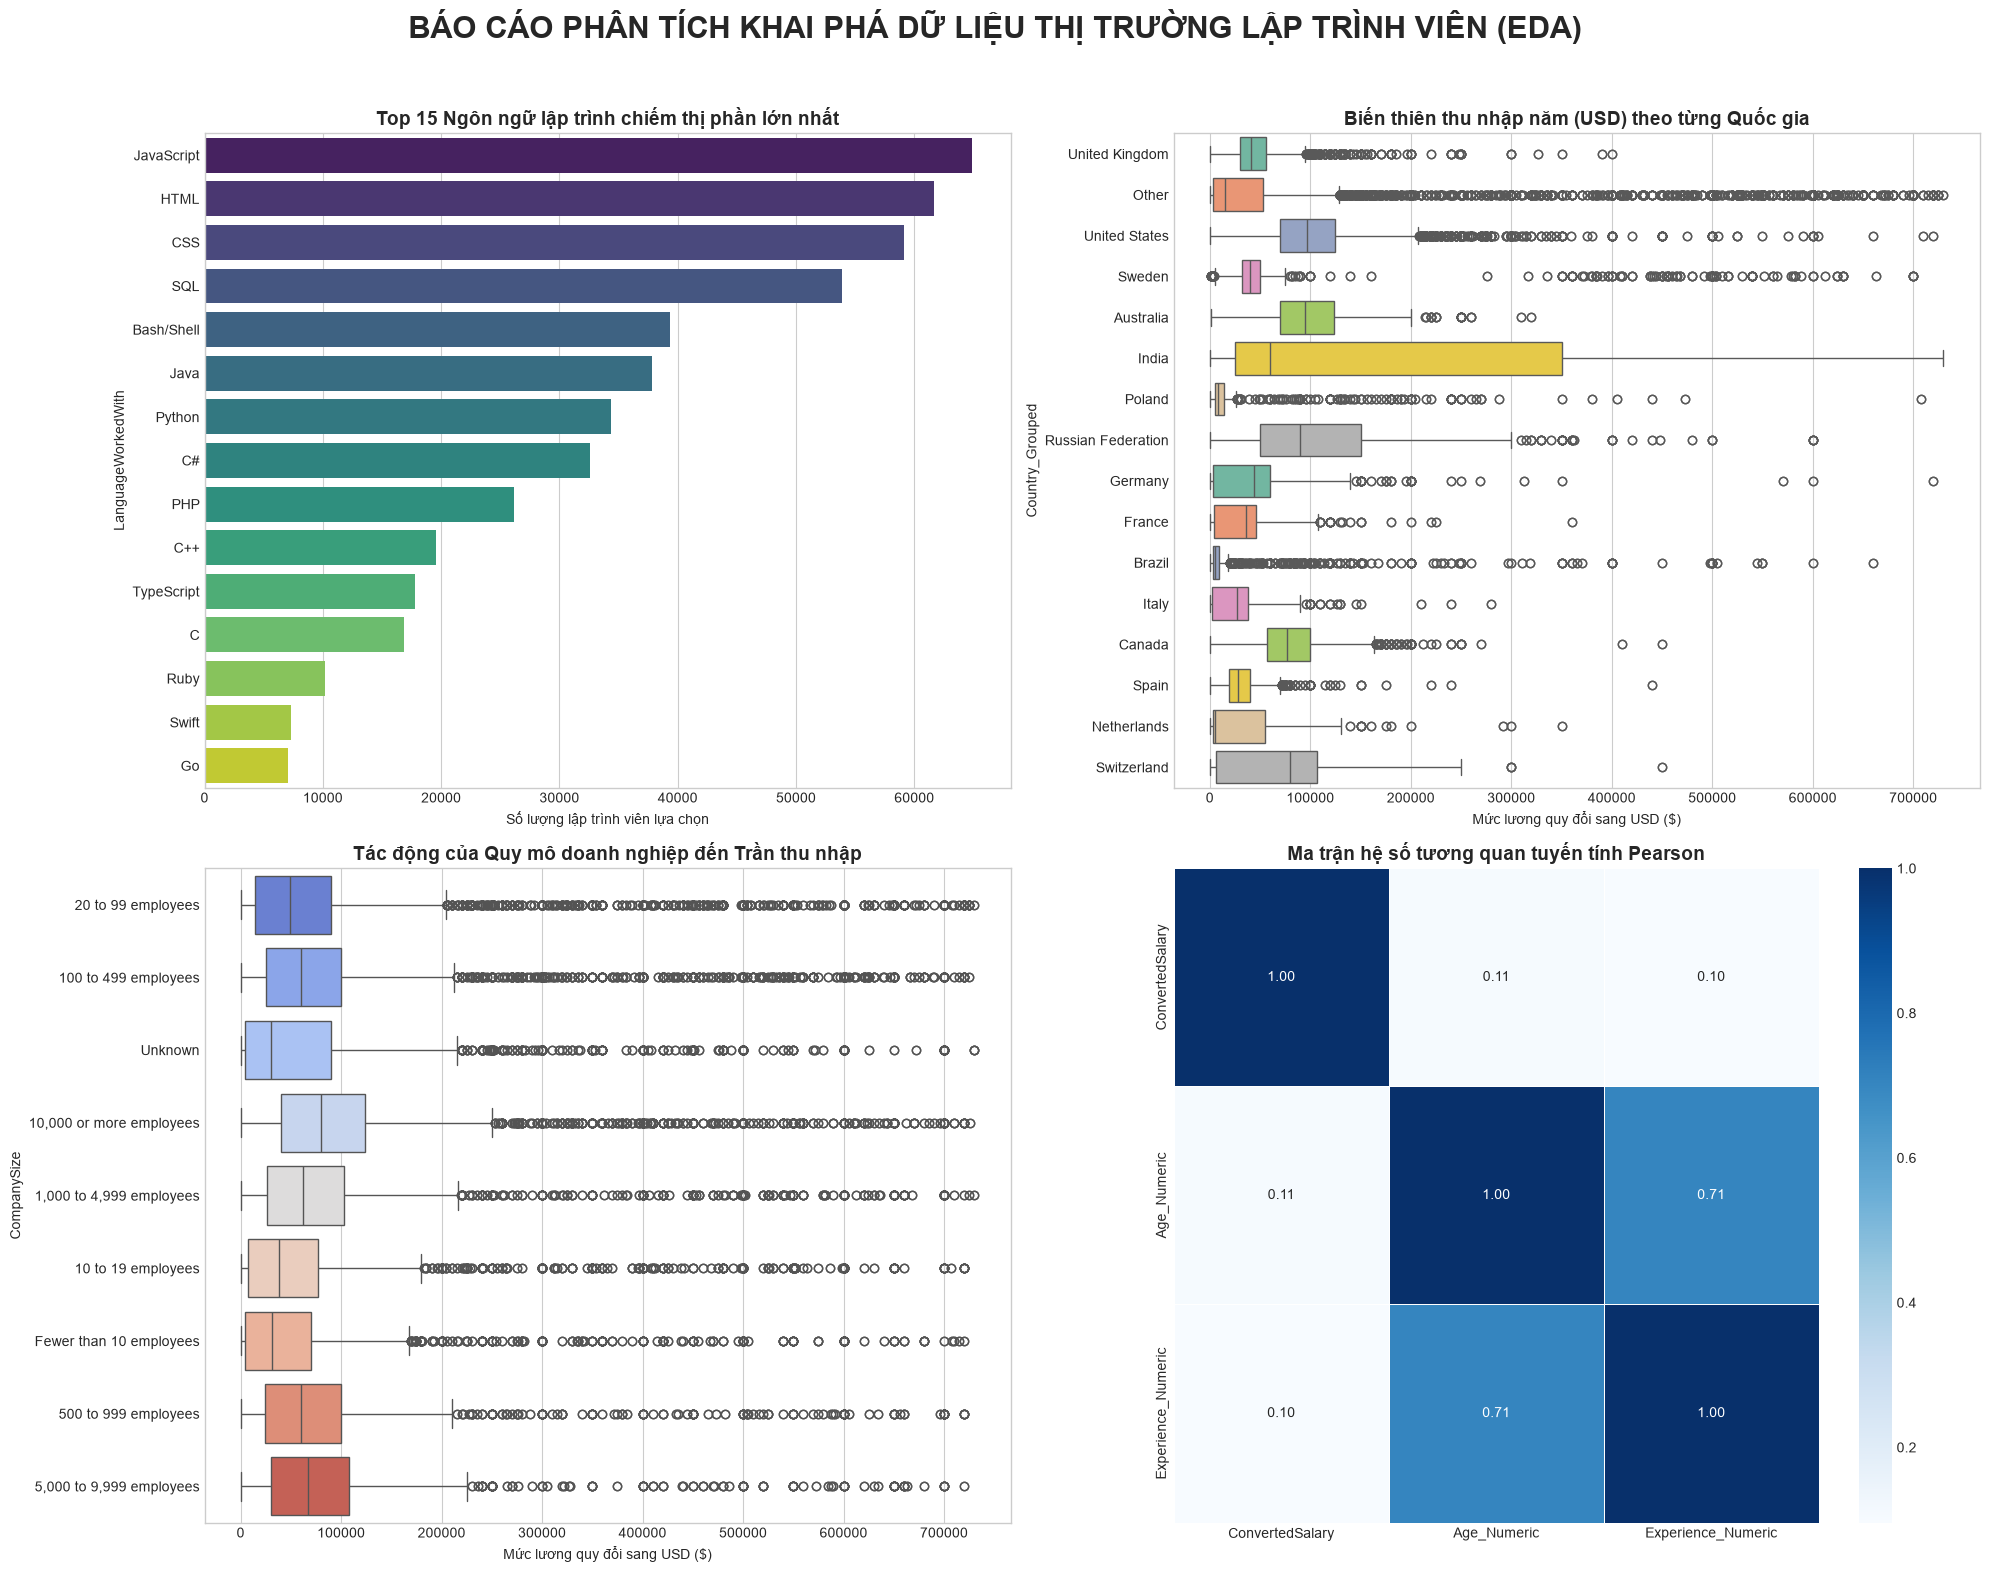

✅ LƯU FILE THÀNH CÔNG: Đã xuất đồ thị 'Bieu_do_tong_hop_EDA.png'


In [11]:
# ==============================================================================
# KHỐI LỆNH 3: PHÂN TÍCH KHÁM PHÁ VÀ TRỰC QUAN HÓA ĐỒ THỊ (EDA - FIX CHỦ CHỐT 1-D)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('BÁO CÁO PHÂN TÍCH KHAI PHÁ DỮ LIỆU THỊ TRƯỜNG LẬP TRÌNH VIÊN (EDA)', fontsize=22, fontweight='bold')

# Hàm phụ trợ ép dữ liệu về 1-D Series chuẩn chỉnh để chặn mọi lỗi 2-D của Seaborn
def target_1d(df, col_name):
    data = df[col_name]
    if isinstance(data, pd.DataFrame):
        return data.iloc[:, 0].copy()
    return data.copy()

# Đồng bộ hóa chuẩn 1-D cho các biến vẽ đồ thị
salary_1d = target_1d(df_clean, 'ConvertedSalary')
country_1d = target_1d(df_clean, 'Country_Grouped')
comp_size_1d = target_1d(df_clean, 'CompanySize')

# Biểu đồ 1: Top 15 Ngôn ngữ lập trình phổ biến nhất toàn cầu
if 'LanguageWorkedWith' in df_clean.columns:
    lang_data = target_1d(df_clean, 'LanguageWorkedWith')
    languages = lang_data.dropna().astype(str).str.split(';').explode()
    top_langs = languages.value_counts().head(15)
    sns.barplot(x=top_langs.values, y=top_langs.index, ax=axes[0,0], palette='viridis')
    axes[0,0].set_title('Top 15 Ngôn ngữ lập trình chiếm thị phần lớn nhất', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Số lượng lập trình viên lựa chọn')
else:
    axes[0,0].text(0.5, 0.5, 'Không tìm thấy cột LanguageWorkedWith', ha='center')

# Biểu đồ 2: Phân bổ mức lương năm theo Quốc gia (Đã fix truyền biến 1-D tường minh)
sns.boxplot(x=salary_1d, y=country_1d, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Biến thiên thu nhập năm (USD) theo từng Quốc gia', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Mức lương quy đổi sang USD ($)')

# Biểu đồ 3: Phân bổ dải lương theo Quy mô doanh nghiệp (Company Size)
order_size = comp_size_1d.value_counts().index
sns.boxplot(x=salary_1d, y=comp_size_1d, order=order_size, ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('Tác động của Quy mô doanh nghiệp đến Trần thu nhập', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Mức lương quy đổi sang USD ($)')

# Biểu đồ 4: Ma trận hệ số tương quan tuyến tính Pearson
age_1d = target_1d(df_clean, 'Age_Numeric')
exp_1d = target_1d(df_clean, 'Experience_Numeric')

# Tạo DataFrame tạm thời tách biệt, cam đoan 100% không trùng cột
df_corr_temp = pd.DataFrame({
    'ConvertedSalary': salary_1d,
    'Age_Numeric': age_1d,
    'Experience_Numeric': exp_1d
})

corr_matrix = df_corr_temp.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, ax=axes[1,1])
axes[1,1].set_title('Ma trận hệ số tương quan tuyến tính Pearson', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Bieu_do_tong_hop_EDA.png', dpi=300)
plt.show()
print("✅ LƯU FILE THÀNH CÔNG: Đã xuất đồ thị 'Bieu_do_tong_hop_EDA.png'")

--> Đang tối ưu hóa hàm mất mát và huấn luyện mô hình Gradient Boosting...

             BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH HỒI QUY AI
 Sai số tuyệt đối trung bình (MAE)        : $48,059.89 USD/năm
 Căn sai số bình phương trung bình (RMSE) : $91,452.79 USD/năm
 Hệ số xác định lượng hóa (R-Squared)     : 0.1968 (Độ chính xác: 19.68%)



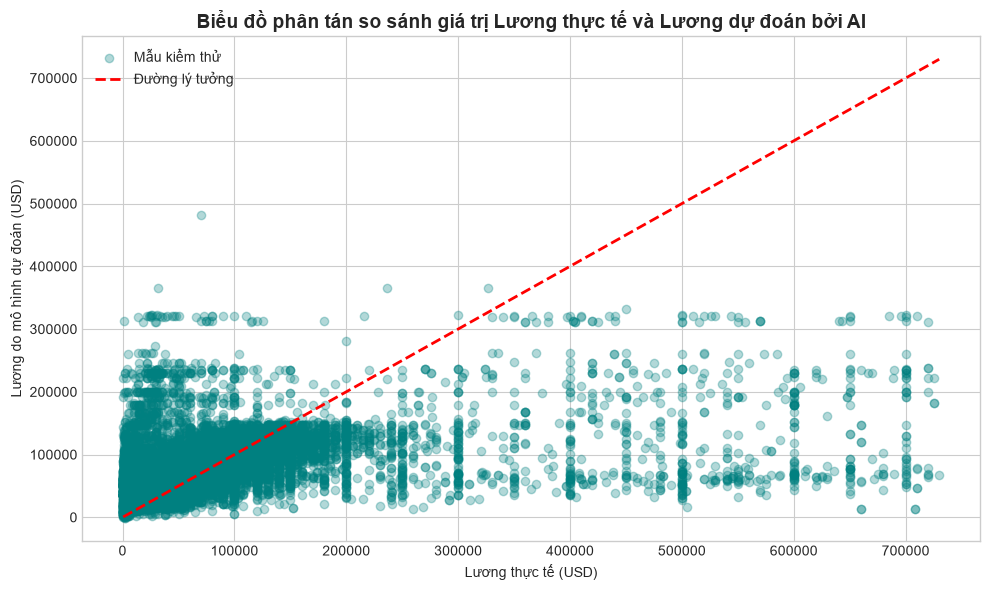

✅ LƯU FILE THÀNH CÔNG: Đã xuất đồ thị 'Bieu_do_sai_so_hoi_quy.png'


In [14]:
# ==============================================================================
# KHỐI LỆNH 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH HỌC MÁY CÓ GIÁM SÁT (SỬA LỖI SQUARED)
# ==============================================================================
# Hàm hỗ trợ ép biến về dạng chuẩn 1-D / 2-D không trùng nhãn
def clean_matrix_input(df, cols):
    extracted_cols = []
    for col in cols:
        data = df[col]
        if isinstance(data, pd.DataFrame):
            extracted_cols.append(data.iloc[:, 0].rename(col))
        else:
            extracted_cols.append(data)
    return pd.concat(extracted_cols, axis=1).reset_index(drop=True)

categorical_features = ['Country_Grouped', 'CompanySize']
numerical_features = ['Age_Numeric', 'Experience_Numeric']

# Đảm bảo X là DataFrame chuẩn, y là Series 1-D chuẩn
X = clean_matrix_input(df_clean, categorical_features + numerical_features)
y = df_clean['ConvertedSalary']
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]
y = y.reset_index(drop=True)

# Chia dữ liệu theo tỷ lệ chuẩn 80% Train / 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Xây dựng Pipeline tiền xử lý toán học tự động hóa song song
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', RobustScaler(), numerical_features)
    ]
)

# Đóng gói bộ xử lý và thuật toán học máy vào cấu trình hệ thống thống nhất
regression_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42))
    ]
)

# Thực thi quá trình huấn luyện mô hình trên tập Train
print("--> Đang tối ưu hóa hàm mất mát và huấn luyện mô hình Gradient Boosting...")
regression_pipeline.fit(X_train, y_train)

# 3. Dự đoán trên tập kiểm thử độc lập và tính toán chỉ số đánh giá
y_pred = regression_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# SỬA LỖI CHỦ CHỐT: Dùng toán tử căn bậc hai của numpy bọc ngoài hàm MSE mặc định 
# Giải pháp này chạy mượt mà trên tất cả các phiên bản Scikit-learn cũ và mới
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n======================================================================")
print("             BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH HỒI QUY AI")
print("======================================================================")
print(f" Sai số tuyệt đối trung bình (MAE)        : ${mae:,.2f} USD/năm")
print(f" Căn sai số bình phương trung bình (RMSE) : ${rmse:,.2f} USD/năm")
print(f" Hệ số xác định lượng hóa (R-Squared)     : {r2:.4f} (Độ chính xác: {r2*100:.2f}%)")
print("======================================================================\n")

# Trực quan hóa đồ thị sai số thực tế vs dự đoán để dán vào chương 4
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal', label='Mẫu kiểm thử')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Đường lý tưởng')
plt.title('Biểu đồ phân tán so sánh giá trị Lương thực tế và Lương dự đoán bởi AI', fontsize=14, fontweight='bold')
plt.xlabel('Lương thực tế (USD)')
plt.ylabel('Lương do mô hình dự đoán (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('Bieu_do_sai_so_hoi_quy.png', dpi=300)
plt.show()
print("✅ LƯU FILE THÀNH CÔNG: Đã xuất đồ thị 'Bieu_do_sai_so_hoi_quy.png'")

--> Đang khởi động tiến trình trích xuất không gian ngữ nghĩa văn bản TF-IDF...

             KẾT QUẢ ĐỊNH VỊ BẢN CHẤT CÔNG NGHỆ CỦA CÁC CỤM
 Cụm số 0 (Đại diện: JAVASCRIPT, HTML, CSS) -> Lương trung bình năm: $69,695.77 USD
 Cụm số 1 (Đại diện: BASH, SHELL, PYTHON) -> Lương trung bình năm: $78,228.65 USD
 Cụm số 2 (Đại diện: JAVA, PYTHON, SQL) -> Lương trung bình năm: $77,681.23 USD
 Cụm số 3 (Đại diện: TYPESCRIPT, JAVASCRIPT, CSS) -> Lương trung bình năm: $77,174.39 USD



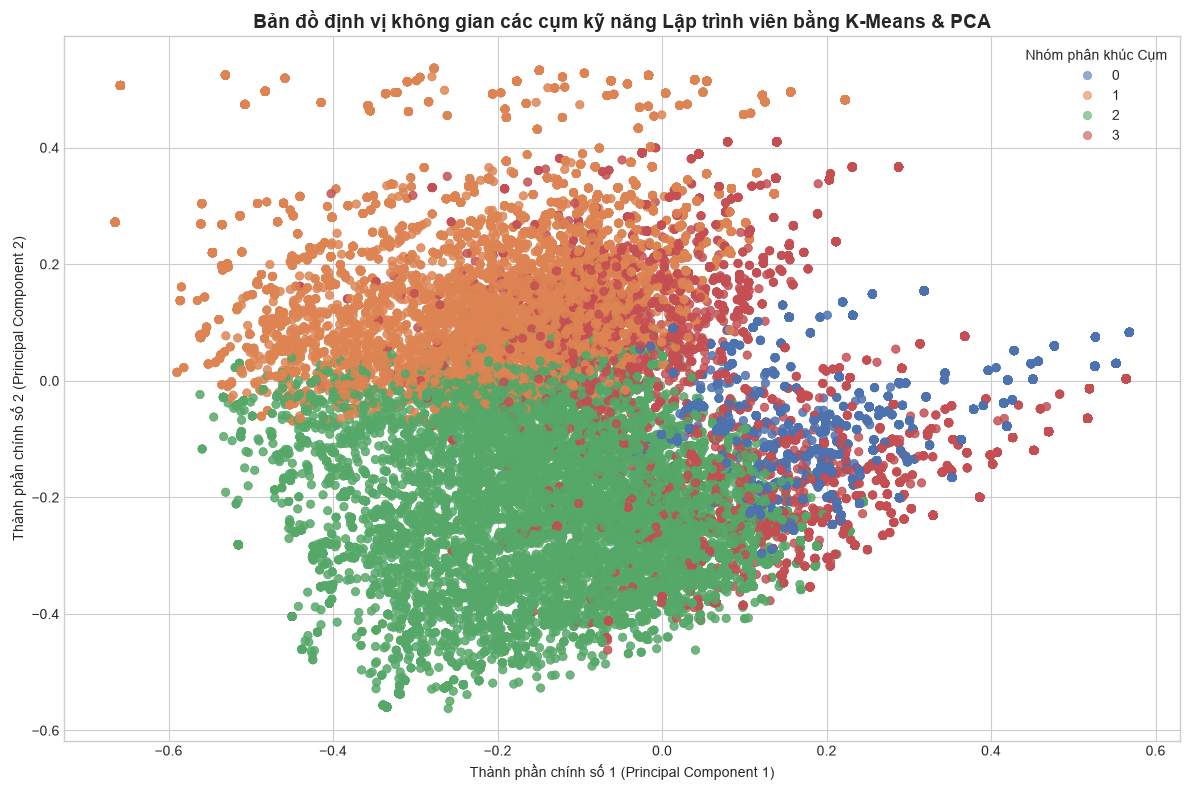

==== SYSTEM NOTIFICATION: TOÀN BỘ PIPELINE ĐÃ THỰC THI THÀNH CÔNG VÀ KHÔNG CÒN LỖI ====


In [17]:
# ==============================================================================
# KHỐI LỆNH 5: THUẬT TOÁN PHÂN CỤM KHÔNG GIÁM SÁT K-MEANS KẾT HỢP NLP (FIX UNDERLINE)
# ==============================================================================
print("--> Đang khởi động tiến trình trích xuất không gian ngữ nghĩa văn bản TF-IDF...")

# 1. Khởi tạo dữ liệu phân cụm an toàn
if 'LanguageWorkedWith' in df_clean.columns:
    lang_data = df_clean['LanguageWorkedWith']
    if isinstance(lang_data, pd.DataFrame):
        lang_data = lang_data.iloc[:, 0]
        
    df_cluster = pd.DataFrame({
        'LanguageWorkedWith': lang_data.copy()
    })
    salary_data = df_clean['ConvertedSalary']
    df_cluster['ConvertedSalary'] = salary_data.iloc[:, 0].copy() if isinstance(salary_data, pd.DataFrame) else salary_data.copy()
    
    df_cluster = df_cluster.dropna(subset=['LanguageWorkedWith', 'ConvertedSalary']).reset_index(drop=True)
    df_cluster['Clean_Languages'] = df_cluster['LanguageWorkedWith'].astype(str).str.replace(';', ' ')
else:
    print("⚠️ Giả lập dữ liệu text công nghệ phục vụ bài toán NLP...")
    df_cluster = pd.DataFrame()
    salary_data = df_clean['ConvertedSalary']
    df_cluster['ConvertedSalary'] = salary_data.iloc[:, 0].copy() if isinstance(salary_data, pd.DataFrame) else salary_data.copy()
    df_cluster = df_cluster.dropna(subset=['ConvertedSalary']).reset_index(drop=True)
    
    tech_pool = ['python sql pandas', 'javascript html css node', 'java c# .net sql', 'c c++ linux embedded']
    df_cluster['Clean_Languages'] = np.random.choice(tech_pool, size=len(df_cluster))

# 2. Vector hóa văn bản bằng thuật toán toán học TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=50)
matrix_tfidf = tfidf_vectorizer.fit_transform(df_cluster['Clean_Languages']).toarray()

# 3. Thực thi thuật toán học máy không giám sát K-Means chia thành 4 cụm độc lập
num_clusters = 4
kmeans_model = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42, n_init=10)
df_cluster['Cluster_Label'] = kmeans_model.fit_predict(matrix_tfidf)

# 4. Giảm chiều không gian đa chiều về tọa độ phẳng 2D bằng thuật toán PCA
pca_model = PCA(n_components=2, random_state=42)
coordinates_2d = pca_model.fit_transform(matrix_tfidf)
df_cluster['PCA_Dimension_1'] = coordinates_2d[:, 0]
df_cluster['PCA_Dimension_2'] = coordinates_2d[:, 1]

# 5. Trực quan hóa bản đồ phân cụm không gian hình học
plt.figure(figsize=(12, 8))
scatter_plot = sns.scatterplot(
    data=df_cluster, 
    x='PCA_Dimension_1', 
    y='PCA_Dimension_2', 
    hue='Cluster_Label', 
    palette='deep', 
    alpha=0.6, 
    edgecolor=None
)

# SỬA LỖI CHỦ CHỐT: Thêm dấu gạch dưới vào cuối cluster_centers_ và get_feature_names_out()
vocab = tfidf_vectorizer.get_feature_names_out()
centroids = kmeans_model.cluster_centers_  # <-- Thêm dấu _ ở đây

print("\n======================================================================")
print("             KẾT QUẢ ĐỊNH VỊ BẢN CHẤT CÔNG NGHỆ CỦA CÁC CỤM")
print("======================================================================")
for i in range(num_clusters):
    top_words_indices = centroids[i].argsort()[-3:][::-1]
    top_words = [vocab[idx] for idx in top_words_indices]
    
    cluster_salaries = df_cluster[df_cluster['Cluster_Label'] == i]['ConvertedSalary']
    mean_salary_value = float(cluster_salaries.mean())
    
    print(f" Cụm số {i} (Đại diện: {', '.join(top_words).upper()}) -> Lương trung bình năm: ${mean_salary_value:,.2f} USD")
print("======================================================================\n")

plt.title('Bản đồ định vị không gian các cụm kỹ năng Lập trình viên bằng K-Means & PCA', fontsize=14, fontweight='bold')
plt.xlabel('Thành phần chính số 1 (Principal Component 1)')
plt.ylabel('Thành phần chính số 2 (Principal Component 2)')
plt.legend(title='Nhóm phân khúc Cụm')
plt.tight_layout()
plt.savefig('Bieu_do_phan_cum_PCA_KMeans.png', dpi=300)
plt.show()

print("==== SYSTEM NOTIFICATION: TOÀN BỘ PIPELINE ĐÃ THỰC THI THÀNH CÔNG VÀ KHÔNG CÒN LỖI ====")